# Pràctica Bloc III

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import zip_longest
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Neteja i transformació de les dades

La primera columna que podem eliminar que no ens aporta absolutament res és `Unnamed: 0`, que és un identificador de les dades.

In [2]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


Una cosa important a tenir en compte és eliminar les dades invàlides ja que qualsevol operació amb una `NaN` (*Not a Number*) resultarà amb un altre `NaN`. Per fer-ho, la forma més intuitiva és veure quines columnes tenen aquests valors.

In [3]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

En aquest cas, l'única columna que conté valors `NaN` és "Arrival Delay in Minutes". Per a no perdre les 393 entrades de dades el que podem fer és reemplaçar cada un d'aquests valors invàlids amb la mitjana de tota la columna.

In [4]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

També és molt important analitzar quin tipus de dades té cada columna. En aquest cas es poden separar en tres tipus:

* Dades categòriques
* Dades de nivell de satisfacció (valors en el rang $[0, 5]$)
* Dades numèriques

In [5]:
# columnes amb nivells de satisfacció [0, 5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# obtenir les columnes sense valors numèrics -> columnes categòriques
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# obtenir les columnes amb valor numèrics
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
# llevam les columnes de nivel de satisfacció per a tenir-ho organitzat en tres tipus 
numcols ^= lvlcols

numcols, lvlcols, catcols = map(list, (numcols, lvlcols, catcols))

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
catvals = { col: list(train_raw[col].unique()) for col in catcols }
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    Gender         : ['Male', 'Female']
    Type of Travel : ['Personal Travel', 'Business travel']
    Class          : ['Eco Plus', 'Business', 'Eco']
    Customer Type  : ['Loyal Customer', 'disloyal Customer']
    satisfaction   : ['neutral or dissatisfied', 'satisfied']
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Leg room service
    Inflight wifi service
    Checkin service
    Inflight entertainment
    Inflight service
    Food and drink
    Departure/Arrival time convenient
    Seat comfort
    On-board service
    Baggage handling
    Ease of Online booking
    Cleanliness
    Online boarding
    Gate location
--------------------------------------------------------------------------------
Columns with numeric values
    Flight Distance
    Departure Delay in Minutes
    Arrival Delay in Minutes
    Age


Degut a que els models no poden processar dades categòriques, és imprescindible transformar-les a dades numèriques. Per fer-ho podem utilitzar `OneHotEncoder` de scikit-learn que crea una columna nova per a cada categoria de cada columna i li assigna el valor 1 quan apareix la categoria i un 0 quan no.

Per intentar reduïr el nombre de columnes podem assignar el paràmetre `drop="if_binary"` que només crearà una columna quan només hi ha dues categories (per exèmple, el sexe del viatger). D'aquesta forma, un 1 indica la classe positiva (la que apareix al nom de la columna resultant) i un 0 la classe negativa.

In [6]:
trgcol = "satisfaction"
trgmap = {"neutral or dissatisfied": 0, "satisfied": 1}

enc = OneHotEncoder(drop="if_binary", sparse_output=False).set_output(transform="pandas")

cat_train = enc.fit_transform(train_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_train = pd.concat([train_raw.drop(columns=catcols), cat_train], axis=1)
y_train = train_raw[trgcol].map(trgmap)

cat_test = enc.transform(test_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_test = pd.concat([test_raw.drop(columns=catcols), cat_test], axis=1)
y_test = test_raw[trgcol].map(trgmap)
X_test = X_test[X_train.columns] # assegurar que train i test tenguin el mateix ordre de les columnes

X_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Customer Type_disloyal Customer
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,1.0,1.0,0.0,0.0,1.0,0.0
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,1.0,0.0,1.0,0.0,0.0,1.0
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,0.0,0.0,1.0,0.0,0.0,0.0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


# Correlació i selecció característiques

Per a poder realitzar un anàlisi de les dades ens ajudarà molt poder reduïr el nombre de columnes. Com que tenim moltes columnes de nivell de satisfacció, 14 en total, potser en poguem agrupar unes quantes que s'assemblin bastant. Per fer-ho, generam una matriu de correlació i analitzam quines de les columnes es relacionen amb les altres.

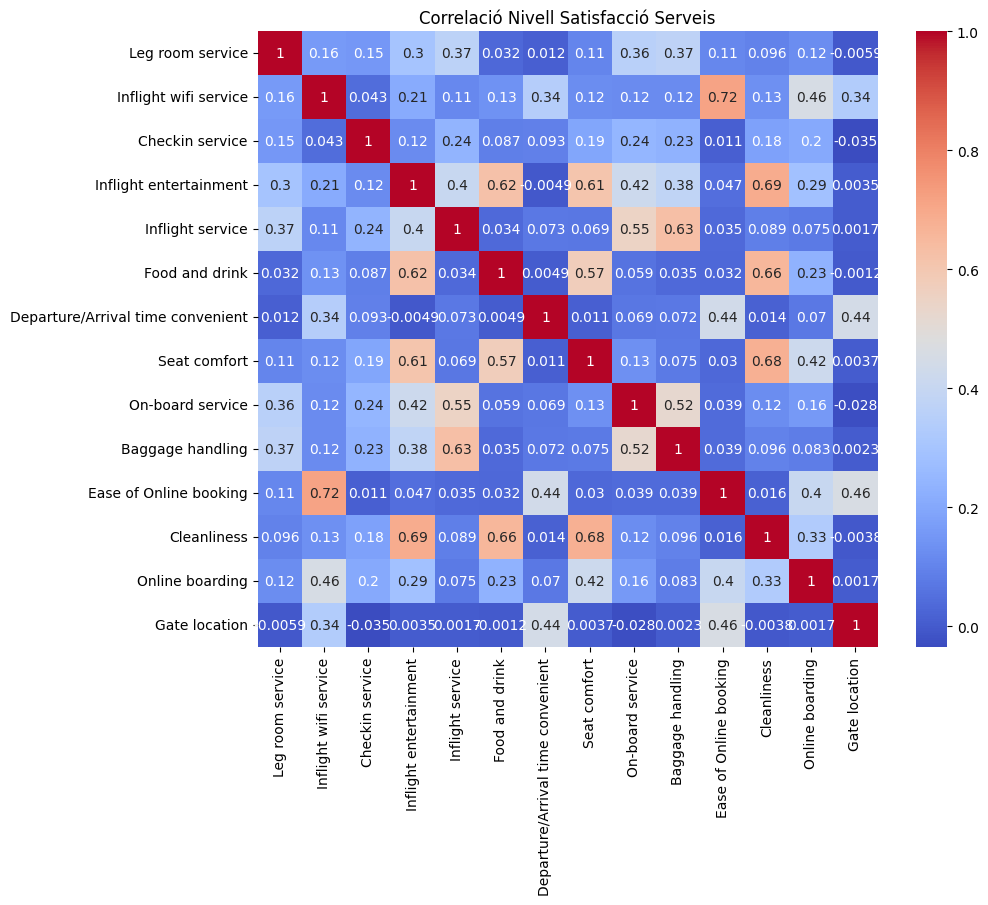

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[lvlcols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlació Nivell Satisfacció Serveis")
plt.show()

Com es pot observar a la matriu de correlació, diverses caracterísitques tenen una correlació important, amb coeficients que oscil·len entre el 60% i el 70%. Tot i que inicialment podria semblar beneficiós fusionar aquestes columnes per reduir la dimensionalitat, aquesta decisió no sempre és la més adequada. En molts casos, aquestes correlacions no responen a una identitat real entre les variables, sinó a l'efecte Halo: un biaix cognitiu on la percepció positiva d'una característica predominant eleva artificialment la valoració de les altres.

Per exemple, la variable *Cleanliness* presenta una correlació forta amb *Seat comfort* (0.68) i *Inflight entertainment* (0.69). Des del punt de vista del passatger, un entorn net genera una sensació de benestar que pot enmascarar deficiències en la comoditat del seient o en la qualitat del contingut multimèdia. Mantenir-les com a variables independents ens permet analitzar si l'aerolínia ha de realitzar inversions diferenciades —manteniment versus tecnologia— en lloc d'assumir que ambdues experiències són indestriables.

Les columnes de nivell de satisfacció es poden agrupar calculant la mitjana de cada grup:

| Columna original                                                   | Grup     |
|--------------------------------------------------------------------|----------|
| Baggage handling<br>Checkin service<br>Inflight service            | Logistic |
| Seat comfort<br>Leg room service<br>On-board service               | Comfort  |
| Ease of Online booking<br>Inflight wifi service<br>Online boarding | Online   |

In [8]:
groups = [
  ("Logistic", ["Baggage handling", "Checkin service", "Inflight service"]),
  ("Comfort", ["Seat comfort", "Leg room service", "On-board service"]),
  ("Online", ["Ease of Online booking", "Inflight wifi service", "Online boarding"])
]
for name, group in groups:
  X_train[name] = X_train[group].mean(axis=1)
  X_test[name] = X_test[group].mean(axis=1)
  X_train = X_train.drop(columns=group)
  X_test = X_test.drop(columns=group)
  lvlcols = list(set(lvlcols) - set(group)) + [name]
X_train.head()

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Food and drink,Inflight entertainment,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Customer Type_disloyal Customer,Logistic,Comfort,Online
0,13,460,4,1,5,5,5,25,18.0,1.0,1.0,0.0,0.0,1.0,0.0,4.333333,4.000000,3.000000
1,25,235,2,3,1,1,1,1,6.0,1.0,0.0,1.0,0.0,0.0,1.0,2.666667,2.333333,3.000000
2,26,1142,2,2,5,5,5,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.000000,4.000000,3.000000
3,25,562,5,5,2,2,2,11,9.0,0.0,0.0,1.0,0.0,0.0,0.0,2.666667,3.000000,3.000000
4,61,214,3,3,4,3,3,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,3.333333,4.000000,3.666667


Ara que hem reduït el nombre de columnes de nivell de satisfacció podem mirar la matriu de correlació de totes les característiques amb la variable que volem prediure (*satisfaction*). A partir d'aqui podrem eliminar encara més columnes.

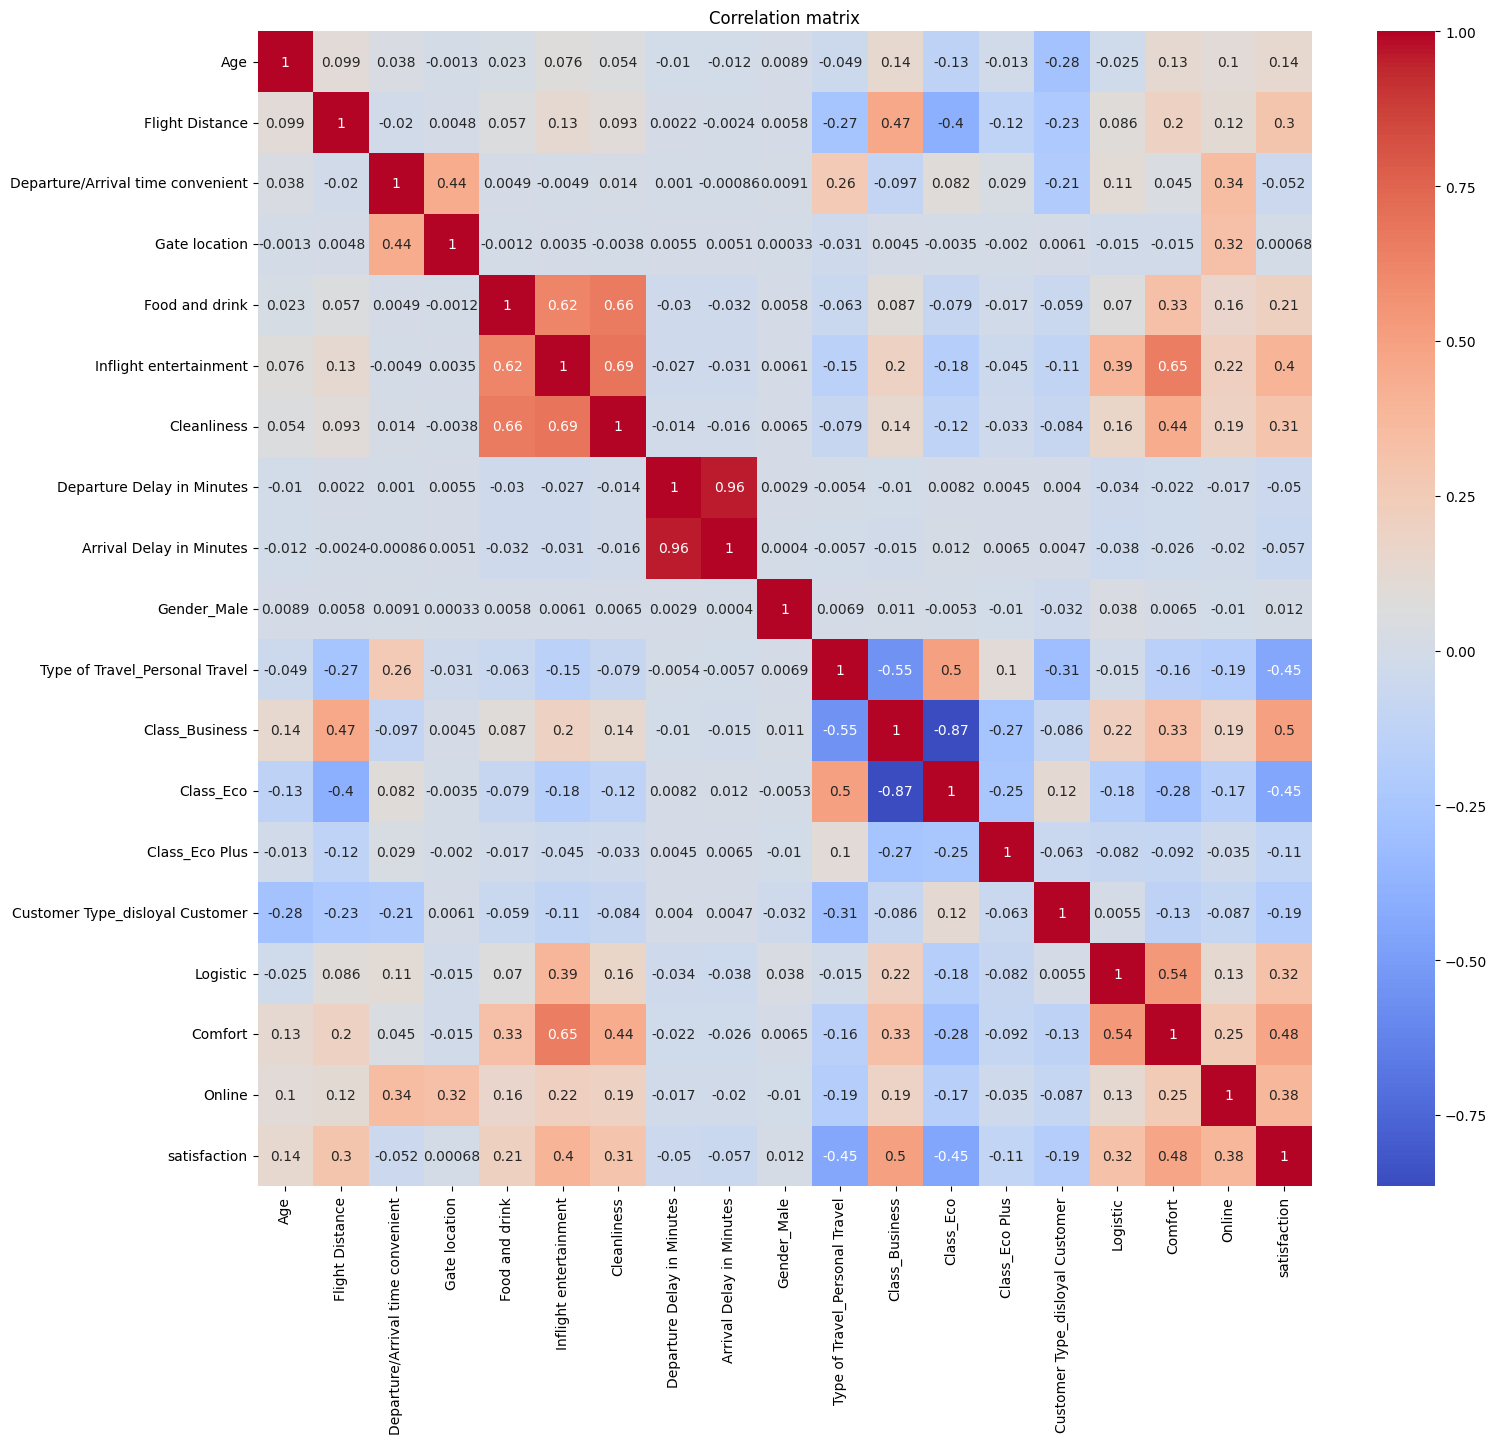

In [9]:
plt.figure(figsize=(17, 15))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

Mirant la correlació de cada caracterísitca amb la satisfacció del passatger s'ha decidit eliminar les següents columnes:

- *Departure/Arrival time convenient*
- *Gate location*
- *Departure Delay in Minutes", "Arrival Delay in Minutes*
- *Gender_Male*

Tot i que *Age* i *Customer Type* tenen una relació relativament baixa amb *satisfaction* s'ha decidit mantenir-les perque són característiques descriptores essencials dels passatgers:

- *Age*: qui és el passatger?
- *Customer Type*: el passatger té qualque tipus de relació amb l'aerolínea?

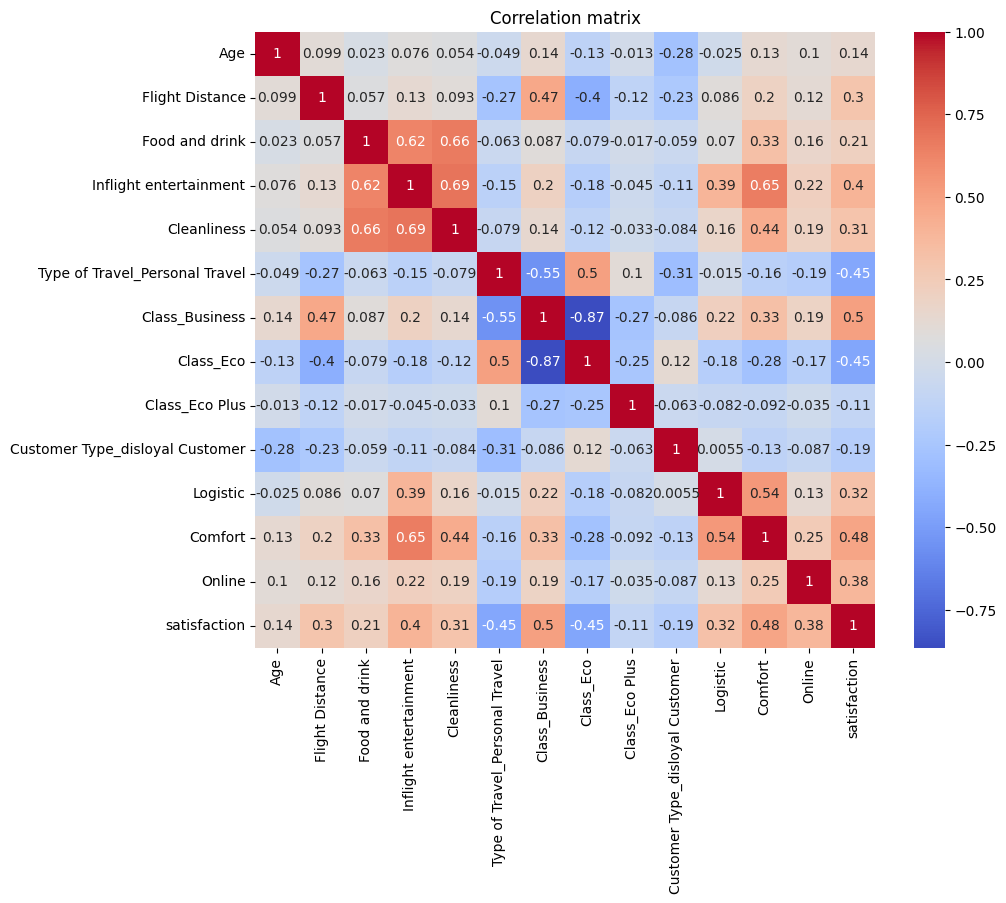

In [10]:
ignore = {
  "Departure/Arrival time convenient",
  "Gate location",
  "Departure Delay in Minutes", "Arrival Delay in Minutes",
  "Gender_Male",
}
X_train = X_train.drop(columns=ignore)
X_test = X_test.drop(columns=ignore)

catcols = set(catcols) - ignore
numcols = set(numcols) - ignore
lvlcols = set(lvlcols) - ignore

plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# Análisi

L'objectiu d'aquest apartat és conèixer en profunditat la naturalesa de les dades i descobrir com estan estructurades. Aquí trobam respostes a preguntes del tipus:

- La classe de passatger (Business, Eco o Eco Plus) és un factor important per al nivell de satisfacció del passatger?
- Hi ha alguna classe de passatger que voli distàncies més llargues?
- L'edat afecta a la satisfacció del passatger?

En altres paraules, aquest anàlisi ens ajudarà a entendre quins perfils de passatgers tenen una satisfacció major. Per tal de tractar amb totes les característiques que tenim i trobar els perfils de passatgers es fa un clustering.

El fet de que l'algorisme de clustering utilitza la distància euclidiana per a trobar els clusters presenta un problema: si hi ha una característica amb un rang numèric $[0, 1000]$ aquesta tindrà un pes molt major en la distància que una que té un rang $[-1, 1]$. Per aquesta raó és imprescindible escalar les dades.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (103904, 13)


Com que ara mateix no coneixem l'estructura de les dades no podem saber quin nombre de clúster és l'indicat. Per a trobar-lo, es realitza el clustering 20 vegades variant el nombre de clusters del 1 al 20 i després es grafica el WCSS (Within-Cluster Sum of Squares), que indica com d'aprop estan les dades del centre de cada grup. Un WCSS baix (punts molt agrupats) significa els grups són homogenis i estan ben definits. En canvi un WCSS alt (punts molt separats) suggereix potser facin falta més clusters.

Ens interessa trobar el mínim nombre de clústers a partir del qual, si l'incrementam, ja no obtenim una millora significativa. En el nostre cas hem definit un punt de tall del 5% de canvi.

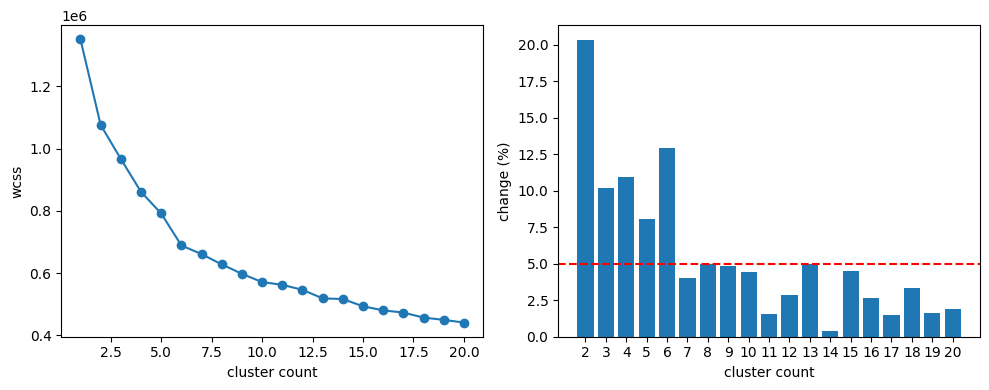

 1 ->  2 :  20.34%
 2 ->  3 :  10.17%
 3 ->  4 :  10.92%
 4 ->  5 :   8.07%
 5 ->  6 :  12.96%
 6 ->  7 :   4.06%
 7 ->  8 :   4.97%
 8 ->  9 :   4.83%
 9 -> 10 :   4.44%
10 -> 11 :   1.54%
11 -> 12 :   2.86%
12 -> 13 :   5.01%
13 -> 14 :   0.41%
14 -> 15 :   4.52%
15 -> 16 :   2.62%
16 -> 17 :   1.52%
17 -> 18 :   3.37%
18 -> 19 :   1.60%
19 -> 20 :   1.92%


In [12]:
from sklearn.cluster import KMeans

cnt = np.arange(1, 20 + 1)
wcss = np.zeros(len(cnt))
for i in cnt:
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X_train_scaled)
  wcss[i-1] = kmeans.inertia_

change_cnt = np.concat([cnt[:-1].reshape(-1, 1), cnt[1:].reshape(-1, 1)], axis=1)
change_pct = (wcss[:-1] - wcss[1:]) / wcss[:-1] * 100

fig, (ax_wcss, ax_change) = plt.subplots(1, 2, figsize=(5 * 2, 4))

ax_wcss.plot(cnt, wcss, marker="o")
ax_wcss.set_xlabel("cluster count")
ax_wcss.set_ylabel("wcss")

ax_change.bar(cnt[1:], change_pct)
ax_change.set_xticks(cnt[1:])
ax_change.set_xlabel("cluster count")
ax_change.set_ylabel("change (%)")
ax_change.axhline(y=5, color="red", linestyle="--")

plt.tight_layout()
plt.show()

for (c1, c2), p in zip(change_cnt, change_pct): print(f"{c1:2d} -> {c2:2d} : {p:6.2f}%")

Com es pot observar, el WCSS decrementa molt aviat a l'inici però després s'estabilitza i decreix més a poc a poc. Segons el punt de tall que hem definit (5% de canvi) el mínim nombre de clústers és 7.

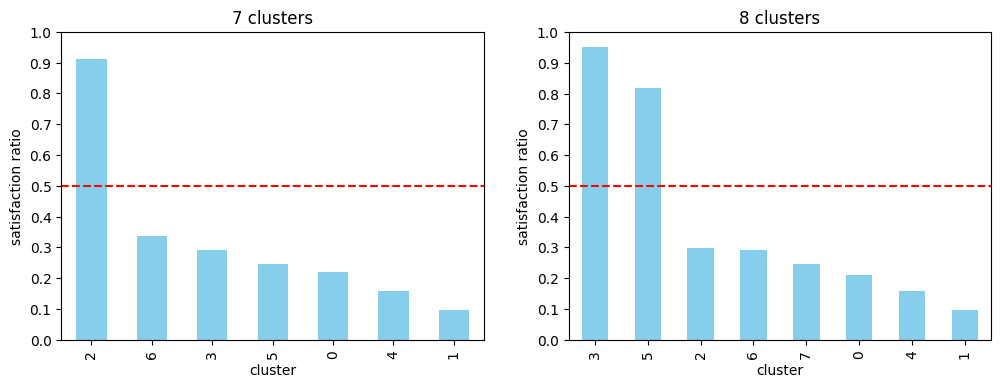

In [13]:
def kmeans_satisfaction(n_clusters, ax, title):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  cluster = pd.concat([X_train, y_train], axis=1)
  cluster["cluster"] = kmeans.fit_predict(X_train_scaled)
  satisfaction_per_cluster = cluster.groupby("cluster")["satisfaction"].mean().sort_values(ascending=False)
  satisfaction_per_cluster.plot(kind="bar", color="skyblue", ax=ax)
  ax.axhline(y=0.5, color="red", linestyle="--")
  ax.set_yticks(np.arange(0.0, 1.1, 0.1))
  ax.set_ylabel("satisfaction ratio")
  ax.set_title(title)
  return cluster

fig, (ax_7, ax_8) = plt.subplots(1, 2, figsize=(6 * 2, 4))
kmeans_satisfaction(7, ax_7, "7 clusters")
kmeans_satisfaction(8, ax_8, "8 clusters")
plt.show()

Per visualitzar la relació entre les característiques dels clusters i la seva satisfacció, es genera un *scatter plot* on cada punt representa un cluster. La mida del punt indica el nombre de passatgers del cluster, i el color indica el nivell de satisfacció (verd = alta, vermell = baixa).

Aquesta visualització ens permetrà identificar patrons: per exemple, si els viatgers de negocis que volen distàncies llargues s'agrupen en clusters amb alta satisfacció.

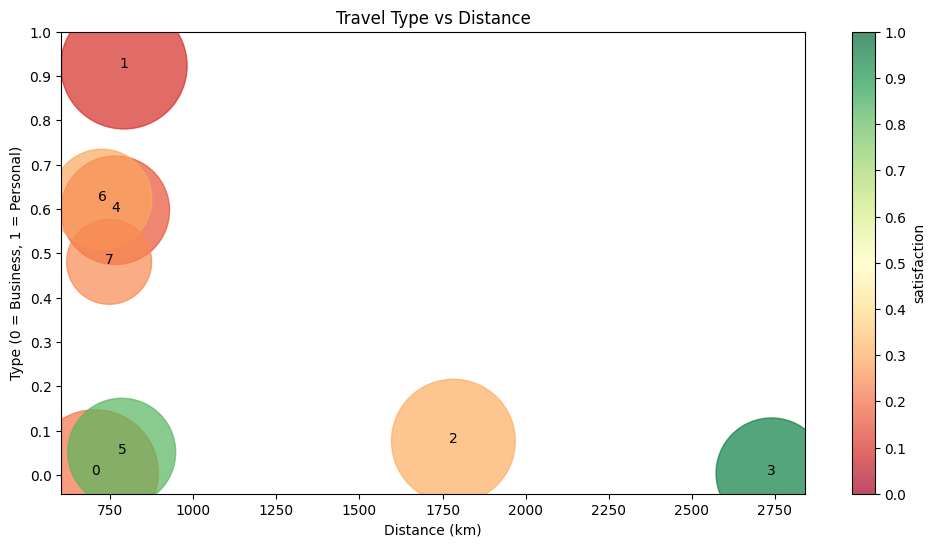

In [14]:
cluster = kmeans_satisfaction(8, ax_8, "8 clusters")
summary = cluster.groupby("cluster").mean()

from matplotlib.axes import Axes
from matplotlib.figure import Figure

def summary_scatter(fig: Figure, ax: Axes, xcol: str, ycol: str, x = None, y = None):
  if x is None: x = summary[xcol]
  if y is None: y = summary[ycol]
  scat = ax.scatter(x, y,
             s=cluster["cluster"].value_counts() * 0.5, c=summary["satisfaction"],
             vmin=0.00, vmax=1.00,
             cmap="RdYlGn", alpha=0.70)
  for i, txt in enumerate(summary.index):
    x, y = summary[xcol][i], summary[ycol][i]
    ax.annotate(txt, xy=(x, y), xytext=(-3, -3), textcoords="offset points", ha="left", va="bottom")
  cbar = fig.colorbar(scat, label="satisfaction")
  cbar.set_ticks(np.arange(0, 1.1, 0.1)) # type: ignore

fig, ax = plt.subplots(figsize=(12, 6))
summary_scatter(fig, ax, "Flight Distance", "Type of Travel_Personal Travel")
ax.set_title("Travel Type vs Distance")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Type (0 = Business, 1 = Personal)")
ax.set_yticks(np.arange(0, 1.10, 0.10))
plt.show()

El gràfic anterior mostra una clara separació entre els clusters segons el tipus de viatge. Els clusters amb alta satisfacció (verds) es concentren a la part inferior del gràfic, corresponent als viatgers de negocis (*Type of Travel* ≈ 0). En canvi, els clusters amb baixa satisfacció (vermells) es troben majoritàriament a la part superior, associats als viatgers personals.

No obstant això, s'observa que alguns clusters de viatgers de negocis també tenen baixa satisfacció. Per entendre aquesta anomalia, analitzam les puntuacions de servei d'aquests clusters.

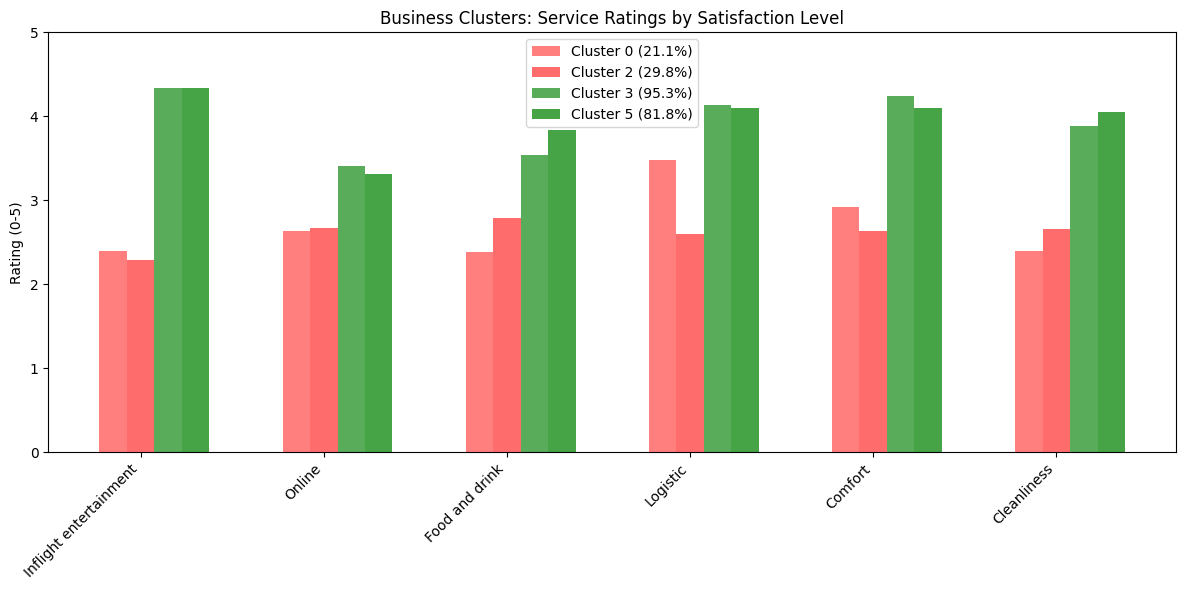

In [15]:
business_clusters = summary[summary["Type of Travel_Personal Travel"] < 0.2].copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lvlcols))
width = 0.15

for i, (idx, row) in enumerate(business_clusters.iterrows()):
  color = "green" if row["satisfaction"] > 0.5 else "red"
  alpha = 0.5 + 0.3 * (i / len(business_clusters))
  ax.bar(x + i * width, [row[col] for col in lvlcols], width,
         label=f"Cluster {idx} ({row['satisfaction']:.1%})", color=color, alpha=alpha)

ax.set_xticks(x + width)
ax.set_xticklabels(lvlcols, rotation=45, ha="right")
ax.set_ylabel("Rating (0-5)")
ax.set_ylim(0, 5)
ax.set_title("Business Clusters: Service Ratings by Satisfaction Level")
ax.legend()
plt.tight_layout()
plt.show()

El gràfic de barres compara les puntuacions de servei entre els clusters de viatgers de negocis. Les barres verdes representen clusters amb alta satisfacció (>50%) i les vermelles clusters amb baixa satisfacció (≤50%).

S'observa clarament que els clusters de negocis amb baixa satisfacció (vermell) tenen puntuacions de servei uniformement baixes (~2-3 sobre 5) en totes les categories. En canvi, els clusters amb alta satisfacció (verd) mostren puntuacions superiors a 3.5 en quasi totes les categories.

Aquesta diferència demostra que **el tipus de viatge no és l'únic factor determinant de la satisfacció**. Dins dels viatgers de negocis, la qualitat percebuda dels serveis és el factor diferenciador clau.

## Conclusions

L'anàlisi de clusters revela que la satisfacció dels passatgers depèn principalment de dos factors:

1. **Tipus de viatge**: Els viatgers de negocis tenen una satisfacció més alta que els viatgers personals. Això pot deure's a expectatives diferents o a una major atenció per part de l'aerolínia cap a aquest segment.

2. **Qualitat del servei**: Dins dels viatgers de negocis, la diferència entre alta i baixa satisfacció és la qualitat percebuda dels serveis (*Logistic*, *Comfort*, *Online*). Els clusters amb puntuacions de servei baixes (~2-3) mostren satisfacció inferior al 30%, mentre que els clusters amb puntuacions altes (~4) superen el 80%.

El cluster 2 (Business, baixa satisfacció) demostra que viatjar en classe Business no garanteix satisfacció si els serveis són percebuts com a deficients. Per contra, el cluster 1 (Personal Travel, classe Eco) és el de menor satisfacció, combinant el tipus de viatge menys favorable amb la classe més econòmica.

Aquestes troballes suggereixen que un model predictiu hauria de tenir en compte tant les característiques demogràfiques del passatger com les puntuacions de servei per predir correctament la satisfacció.

# Selecció hiperparàmetres i entrenament

En aquesta secció s'entrenen i comparen els cinc models requerits: Perceptró, Regressió Logística, SVM, Arbre de Decisió i Random Forest.

Per a cada model es segueix el següent procés:
1. **Selecció d'hiperparàmetres**: S'utilitza `GridSearchCV` amb validació creuada de 5 folds per trobar la millor combinació d'hiperparàmetres.
2. **Entrenament**: El model es torna a entrenar amb els millors hiperparàmetres trobats.
3. **Avaluació**: S'avalua el model amb múltiples mètriques per a qualificar el seu rendiment.

Per aquest problema de classificació binària (satisfet o no satisfet) s'utilitzen les següents mètriques:

- **Accuracy**: Proporció de prediccions correctes.
- **Precision**: Important per evitar falsos positius: no volem dir que un passatger està satisfet quan realment no ho està.
- **Recall**: Important per detectar tots els passatgers insatisfets i poder actuar per millorar la seva experiència.
- **F1-Score**: Harmònica entre precision i recall, útil per tenir una visió global del rendiment.

In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

Per a cada model s'han seleccionat els següents hiperparàmetres (s'ha intentat escollir els més rellevants segons la seva influència en el rendiment):

### Perceptró

**`penalty`** (tipus de regularització): Defineix com es penalitzen els pesos del model.
- `None`: Sense regularització, el model és lliure de créixer sense restriccions (risc d'overfitting).
- `l2`: Penalitza la suma dels pesos al quadrat.
- `l1`: Penalitza la suma del valor absolut dels pesos.
- `elasticnet`: Combina L1 i L2, aprofita els avantatges de tots dos.

**`alpha`** (força de regularització): Controla l'overfitting penalitzant pesos grans.
- Valors més baixos permeten al model aprendre patrons més complexos però poden provocar verfitting.
- Valors més alts forcen més simplicitat al model i milloren la generalització.

### Regressió Logística

**`C`** (inversa de la força de regularització): És l'invers d'`alpha`.
- Valors més baixos forcen més simplicitat al model i milloren la generalització.
- Valors més alts permeten al model aprendre patrons més complexos però poden provocar overfitting.

**`solver`** (algoritme d'optimització): Afecta la velocitat de convergència i quines penalitats suporta.
- `lbfgs`: (Limited-memory Broyden-Fletcher-Goldfarb-Shanno) eficient per datasets petits/mitjans, només suporta L2.
- `liblinear`: (Library for Large Linear Classification) bo per datasets petits, suporta L1 i L2.
- `saga`: (Stochastic Average Gradient Augmented) eficient per datasets grans, suporta L1, L2 i elasticnet.

### SVM (Support Vector Machine)

**`C`** (penalització d'errors): Controla el balanç entre maximitzar el marge i minimitzar errors de classificació.
- Valors més baixos prioritzen un marge ampli i toleren més errors.
- Valors més alts prioritzen classificar correctament i toleren menys error, però pot provocar overfitting.

**`kernel`** (funció del kernel): Defineix com es mapegen les dades a un espai dimensional superior.
- `linear`: Decisió lineal, assumeix que les dades són linealment separables (ràpid, simple).
- `rbf` (Radial Basis Function): Crea fronteres circulars/el·líptiques, capta relacions no lineals complexes.
- `poly` (Polinomial): Crea fronteres polinòmiques, útil per relacions d'interacció entre característiques.

### Arbre de Decisió

**`max_depth`** (profunditat màxima): Limita quantes divisions pot fer l'arbre.
- Valors més baixos creen arbres superficials i simples amb menys risc d'overfitting, però poden no capturar patrons complexos.
- Valors més alts permeten arbres profunds que capturen relacions complexes, però amb més risc d'overfitting.
- `None`: L'arbre creix sense límit. Això implica un alt risc d'overfitting.

**`min_samples_split`** (mínim de mostres per dividir un node): Controla quan un node es pot dividir.
- Valors més baixos permeten divisions molt granulars i aprenen soroll, però amb risc d'overfitting.
- Valors més alts forcen divisions més robustes basades en més dades (millor generalització).

### Random Forest

**`n_estimators`** (nombre d'arbres): Més arbres redueixen la variància i milloren l'estabilitat.
- Valors més baixos creen models més ràpids però menys estables.
- Valors més alts creen models més estables i robustos però més lents.

**`max_depth`** (profunditat màxima de cada arbre): Controla la complexitat individual de cada arbre.
- Valors més baixos creen arbres simples.
- Valors més alts permeten arbres complexos que capturen patrons detallats.
- `None`: Arbres sense límit.

In [17]:
models_params = {
    "Perceptron": (
        Perceptron(max_iter=1000, random_state=42),
        {
            "alpha": [0.0001, 0.001, 0.01, 0.1],
            "penalty": [None, "l2", "l1", "elasticnet"]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear", "saga"]
        }
    ),
    "SVM": (
        SVC(random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None]
        }
    )
}

results = {}

for name, (model, params) in models_params.items():
    print(f"{"-"*60}")
    print(name)
    print(f"{"-"*60}")

    start = time.perf_counter()
    gs = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
    gs.fit(X_train_scaled, y_train)
    end = time.perf_counter()

    best_model = gs.best_estimator_
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)

    results[name] = {
        "params": gs.best_params_,
        "cv_acc": gs.best_score_,
        "train_acc": accuracy_score(y_train, y_train_pred),
        "test_acc": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "y_test_pred": y_test_pred,
        "model": best_model
    }

    print()
    print(f"search time: {end - start:6.4f}s")
    print(f"best params: {results[name]["params"]}")
    print(f"     cv acc: {results[name]["cv_acc"]:.4f}")
    print(f"  train acc: {results[name]["train_acc"]:.4f}")
    print(f"   test acc: {results[name]["test_acc"]:.4f}")
    print()

results = (pd.DataFrame.from_dict(results, orient="index").reset_index()
                       .rename(columns={"model": "instance"})
                       .rename(columns={"index": "model"})
                       .set_index("model"))
results

------------------------------------------------------------
Perceptron
------------------------------------------------------------
Fitting 5 folds for each of 16 candidates, totalling 80 fits

search time: 2.0614s
best params: {'alpha': 0.001, 'penalty': 'elasticnet'}
     cv acc: 0.8242
  train acc: 0.8275
   test acc: 0.8230

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

search time: 0.9610s
best params: {'C': 0.01, 'solver': 'lbfgs'}
     cv acc: 0.8623
  train acc: 0.8623
   test acc: 0.8564

------------------------------------------------------------
SVM
------------------------------------------------------------
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



search time: 531.0121s
best params: {'C': 10, 'kernel': 'rbf'}
     cv acc: 0.9256
  train acc: 0.9300
   test acc: 0.9265

------------------------------------------------------------
Decision Tree
------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

search time: 1.9781s
best params: {'max_depth': 15, 'min_samples_split': 10}
     cv acc: 0.9226
  train acc: 0.9496
   test acc: 0.9254

------------------------------------------------------------
Random Forest
------------------------------------------------------------
Fitting 5 folds for each of 9 candidates, totalling 45 fits

search time: 33.5248s
best params: {'max_depth': 20, 'n_estimators': 200}
     cv acc: 0.9335
  train acc: 0.9813
   test acc: 0.9334



,params,cv_acc,train_acc,test_acc,precision,recall,f1,y_test_pred,instance
model,,,,,,,,,
Perceptron,"{'alpha': 0.001, 'penalty': 'elasticnet'}",0.824165,0.827533,0.822952,0.769572,0.851706,0.808558,"[1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","Perceptron(alpha=0.001, penalty='elasticnet', ..."
Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",0.862296,0.862286,0.856406,0.849504,0.817767,0.833333,"[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","LogisticRegression(C=0.01, max_iter=1000, rand..."
SVM,"{'C': 10, 'kernel': 'rbf'}",0.925585,0.929983,0.926509,0.926888,0.903885,0.915242,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, ...","SVC(C=10, random_state=42)"
Decision Tree,"{'max_depth': 15, 'min_samples_split': 10}",0.922650,0.949598,0.925354,0.930573,0.896869,0.913410,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","DecisionTreeClassifier(max_depth=15, min_sampl..."
Random Forest,"{'max_depth': 20, 'n_estimators': 200}",0.933544,0.981339,0.933362,0.940999,0.904937,0.922616,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...","(DecisionTreeClassifier(max_depth=20, max_feat..."


## Resum dels resultats

### Temps d'execució

La cerca d'hiperparàmetres mostra diferències de temps molt significatives:

- **Models lineals** (Perceptró: 2.1s, Regressió Logística: 1.0s): Molt ràpids per la seva simplicitat computacional.
- **Arbre de Decisió** (2.0s): Ràpid perquè cada divisió és una operació simple de comparació.
- **Random Forest** (33.5s): bastant més lent que un arbre individual perquè entrena molts més arbres.
- **SVM** (531s = 8 minuts amb 58 segons): extremadament més lent que la resta de models, especialment degut al kernel no lineal RBF i la quantitat elevada de mostres (>100,000).

### Interpretació dels hiperparàmetres

Els millors hiperparàmetres trobats tenen sentit donades les característiques del problema:

**Perceptró** (`alpha=0.001, penalty='elasticnet'`): Regularització baixa amb ElasticNet suggereix que les dades tenen soroll i correlacions entre features, beneficiant-se de la combinació L1+L2.

**Regressió Logística** (`C=0.01, solver='lbfgs'`): **C molt baix = regularització molt alta**, indica que el model lineal necessita simplicitat per no memoritzar soroll. L'optimitzador LBFGS convergeix ràpidament amb L2.

**SVM** (`C=10, kernel='rbf'`): C alt prioritza classificar correctament (tolera pocs errors). El kernel RBF capta les relacions no lineals que els models lineals no poden.

**Arbre de Decisió** (`max_depth=15, min_samples_split=10`): Profunditat moderada amb splits conservadors evita overfitting.

**Random Forest** (`n_estimators=200, max_depth=20`): Molts arbres profunds aprofiten l'ensemble averaging per capturar patrons complexos sense overfitting excessiu.

## Visualització comparativa

A continuació es presenten gràfics per comparar el rendiment dels models i detectar possibles problemes com l'overfitting.

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results))
width = 0.35
models_names = results.index.values

ax1 = axes[0]
train_acc = [results["train_acc"][m] for m in models_names]
test_acc = [results["test_acc"][m] for m in models_names]

bars1 = ax1.bar(x - width/2, train_acc, width, label="Train", color="steelblue")
bars2 = ax1.bar(x + width/2, test_acc, width, label="Test", color="coral")

ax1.set_ylabel("accuracy")
ax1.set_title("Train vs Test Accuracy (Overfitting)")
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha="right")
ax1.legend()
ax1.set_ylim(0.5, 1.0)

for i, (tr, te) in enumerate(zip(train_acc, test_acc)):
  if tr - te > 0.05:
    ax1.annotate("!", xy=(i, tr), fontsize=14, ha="center")

ax2 = axes[1]
metrics = ["test_acc", "precision", "recall", "f1"]
x2 = np.arange(len(models_names))
width = 0.2

for i, metric in enumerate(metrics):
  values = results[metric].values
  ax2.bar(x2 + i * width, values, width, label=metric)

ax2.set_ylabel("score")
ax2.set_title("Comparació de Mètriques per Model")
ax2.set_xticks(x2 + width * 1.5)
ax2.set_xticklabels(models_names, rotation=45, ha="right")
ax2.legend(loc="lower right")
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

**Gràfic comparativa accuracy entre train i test (esquerre)**

Els models lineals (Perceptró i Regressió Logística) mostren un accuracy inferior al 85%, indicant que no poden capturar les relacions no lineals del problema. En canvi, els models no lineals (SVM, Decision Tree, Random Forest) superen el 90%, confirmant que la satisfacció depèn d'interaccions complexes entre característiques. En quant a l'overfitting, Random Forest mostra la diferència train-test més gran degut als 200 arbres profunds que memoritzen patrons específics. Decision Tree també presenta overfitting, però més baix. SVM amb kernel RBF és el model més equilibrat gràcies a la regularització del paràmetre `C=10` que penalitza errors dins del marge.

**Gràfic comparativa mètriques (dreta)**

El Perceptró mostra un desequilibri notable amb recall alt però precision baixa, indicant que prediu "satisfet" massa sovint (molts falsos positius). La Regressió Logística equilibra millor precision i recall probablement gràcies a la seva regularització forta (`C=0.01`). En quant als models no lineals, tots tres mantenen les quatre mètriques per damunt del 90% i ben equilibrades.

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

sorted_results = results.sort_values("test_acc", ascending=False)

for i, (model_name, row) in enumerate(sorted_results.iterrows()):
    ax = axes[i]
    cm = confusion_matrix(y_test, row["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["not satisfied", "satisfied"],
                yticklabels=["not satisfied", "satisfied"])
    ax.set_title(f"{model_name}\n(acc: {row['test_acc']:.2%})")
    ax.set_ylabel("real")
    ax.set_xlabel("prediction")

axes[-1].axis("off")

plt.tight_layout()

NameError: name 'plt' is not defined

Per als models no lineals la matriu de confusió és molt semblant (té sentit donat que els seus `accuracy` són pràcticament iguals) i tots tres prioritzen els falsos negatius.

Per als models lineals la matriu de confusió té valors més elevats a les cel·les fora de la diagonal (més errors), cosa que explica un `accuracy` inferior. La regressió logística, al igual que els models no lineals, prioritza els falsos negatius. En canvi, el perceptró prioritza els falsos positius. Tot i que ambdós models tenen un `accuracy` semblant la diferència de preferència entre falsos negatius i positius pot ser un determinant clau a l'hora d'escollir un model o l'altre (pot ser preferible per l'aorilínea evitar els falsos positius per tal d'assegurar-se que tots els passatgers estiguin satisfets).

In [1]:
rf_model = results["instance"]["Random Forest"]
feature_importance = pd.DataFrame({
  "feature": X_train.columns,
  "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance["feature"], feature_importance["importance"], color="steelblue")
ax.set_xlabel("importance")
ax.set_title("Feature importance (Random Forest)")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for _, row in feature_importance.tail(5).iloc[::-1].iterrows():
  print(f"  - {row["feature"]}: {row["importance"]:.4f}")

NameError: name 'results' is not defined